In [ ]:
!pip install wfdb

import wfdb

import numpy as np

import matplotlib.pyplot as plt

import torch

import torch.nn as nn

from scipy.signal import butter,lfilter

from sklearn.model_selection import train_test_split

from torch.utils.data import Dataset, DataLoader

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 66.3 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.


In [ ]:
record = wfdb.rdrecord(

    '100',

    pn_dir='mitdb'

)

ecg_signal = record.p_signal[:,0]

print("ECG Shape:", ecg_signal.shape)

print("Sampling Frequency:", record.fs)

ECG Shape: (650000,)
Sampling Frequency: 360


In [ ]:
artifact_record = wfdb.rdrecord(

    'ma',

    pn_dir='nstdb'

)

bw_record = wfdb.rdrecord(

    'bw',

    pn_dir='nstdb'

)

em_record = wfdb.rdrecord(

    'em',

    pn_dir='nstdb'

)


artifact_signal = artifact_record.p_signal[:,0]

artifact_bw = bw_record.p_signal[:,0]

artifact_em = em_record.p_signal[:,0]


print("MA:",artifact_signal.shape)

print("BW:",artifact_bw.shape)

print("EM:",artifact_em.shape)

MA: (650000,)
BW: (650000,)
EM: (650000,)


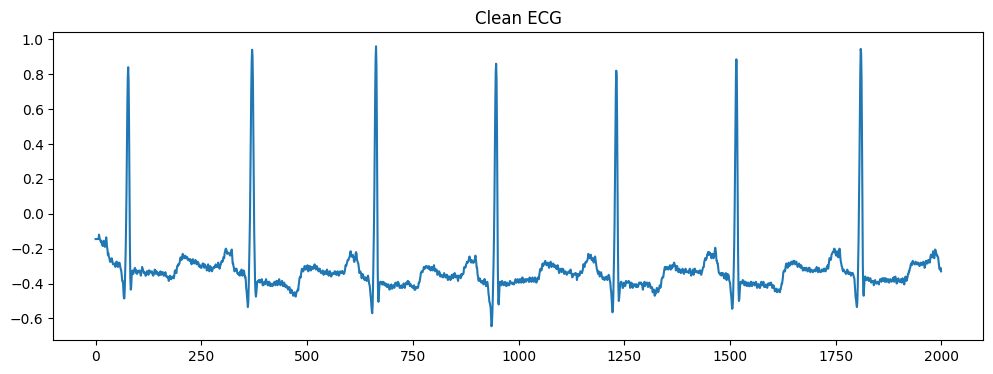

In [ ]:
plt.figure(figsize=(12,4))

plt.plot(ecg_signal[:2000])

plt.title("Clean ECG")

plt.show()

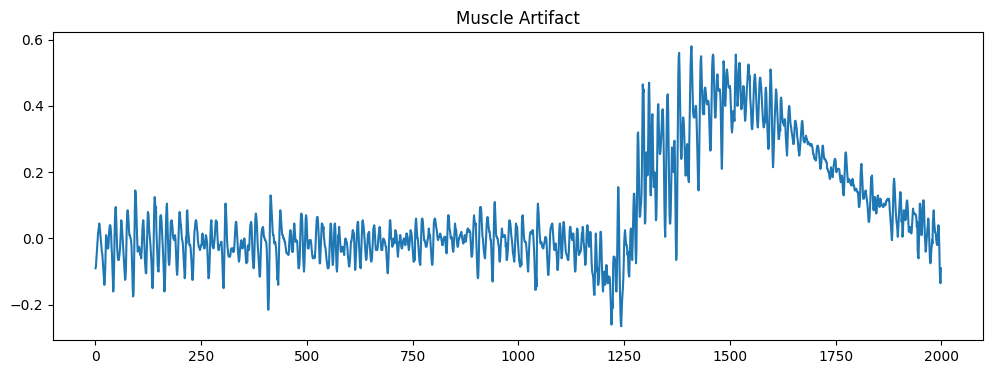

In [ ]:
plt.figure(figsize=(12,4))

plt.plot(artifact_signal[:2000])

plt.title("Muscle Artifact")

plt.show()

In [ ]:
strengths=[

0.25,

0.5,

1.0,

2.0

]


artifacts={

"MA":artifact_signal,

"BW":artifact_bw,

"EM":artifact_em

}


noisy_ecg_list=[]

artifact_names=[]


for artifact_name,artifact_data in artifacts.items():

    for strength in strengths:


        artifact_scaled=(

            strength

            *

            artifact_data

        )


        noisy_ecg=(

            ecg_signal

            +

            artifact_scaled

        )


        noisy_ecg_list.append(

            noisy_ecg

        )


        artifact_names.append(

            f"{artifact_name}_{strength}"

        )


print(

    "Total Single ECGs:",

    len(noisy_ecg_list)

)

print()

print(

    artifact_names

)

Total Single ECGs: 12

['MA_0.25', 'MA_0.5', 'MA_1.0', 'MA_2.0', 'BW_0.25', 'BW_0.5', 'BW_1.0', 'BW_2.0', 'EM_0.25', 'EM_0.5', 'EM_1.0', 'EM_2.0']


In [ ]:
mixed_artifact_list = []

mixed_noisy_ecg_list = []

mixed_artifact_names = []

In [ ]:
for strength in strengths:

    mixed_artifact = (

        strength

        *

        (

            artifact_signal

            +

            artifact_bw

        )

    )


    noisy_ecg = (

        ecg_signal

        +

        mixed_artifact

    )


    mixed_artifact_list.append(

        mixed_artifact

    )

    mixed_noisy_ecg_list.append(

        noisy_ecg

    )

    mixed_artifact_names.append(

        f"MABW_{strength}"

    )

In [ ]:
for strength in strengths:

    mixed_artifact = (

        strength

        *

        (

            artifact_signal

            +

            artifact_em

        )

    )


    noisy_ecg = (

        ecg_signal

        +

        mixed_artifact

    )


    mixed_artifact_list.append(

        mixed_artifact

    )

    mixed_noisy_ecg_list.append(

        noisy_ecg

    )

    mixed_artifact_names.append(

        f"MAEM_{strength}"

    )

In [ ]:
for strength in strengths:

    mixed_artifact = (

        strength

        *

        (

            artifact_bw

            +

            artifact_em

        )

    )


    noisy_ecg = (

        ecg_signal

        +

        mixed_artifact

    )


    mixed_artifact_list.append(

        mixed_artifact

    )

    mixed_noisy_ecg_list.append(

        noisy_ecg

    )

    mixed_artifact_names.append(

        f"BWEM_{strength}"

    )

In [ ]:
for strength in strengths:

    mixed_artifact = (

        strength

        *

        (

            artifact_signal

            +

            artifact_bw

            +

            artifact_em

        )

    )


    noisy_ecg = (

        ecg_signal

        +

        mixed_artifact

    )


    mixed_artifact_list.append(

        mixed_artifact

    )

    mixed_noisy_ecg_list.append(

        noisy_ecg

    )

    mixed_artifact_names.append(

        f"ALL_{strength}"

    )

In [ ]:
print(

    len(mixed_artifact_list)

)

print(

    len(mixed_noisy_ecg_list)

)

print(

    mixed_artifact_names

)

16
16
['MABW_0.25', 'MABW_0.5', 'MABW_1.0', 'MABW_2.0', 'MAEM_0.25', 'MAEM_0.5', 'MAEM_1.0', 'MAEM_2.0', 'BWEM_0.25', 'BWEM_0.5', 'BWEM_1.0', 'BWEM_2.0', 'ALL_0.25', 'ALL_0.5', 'ALL_1.0', 'ALL_2.0']


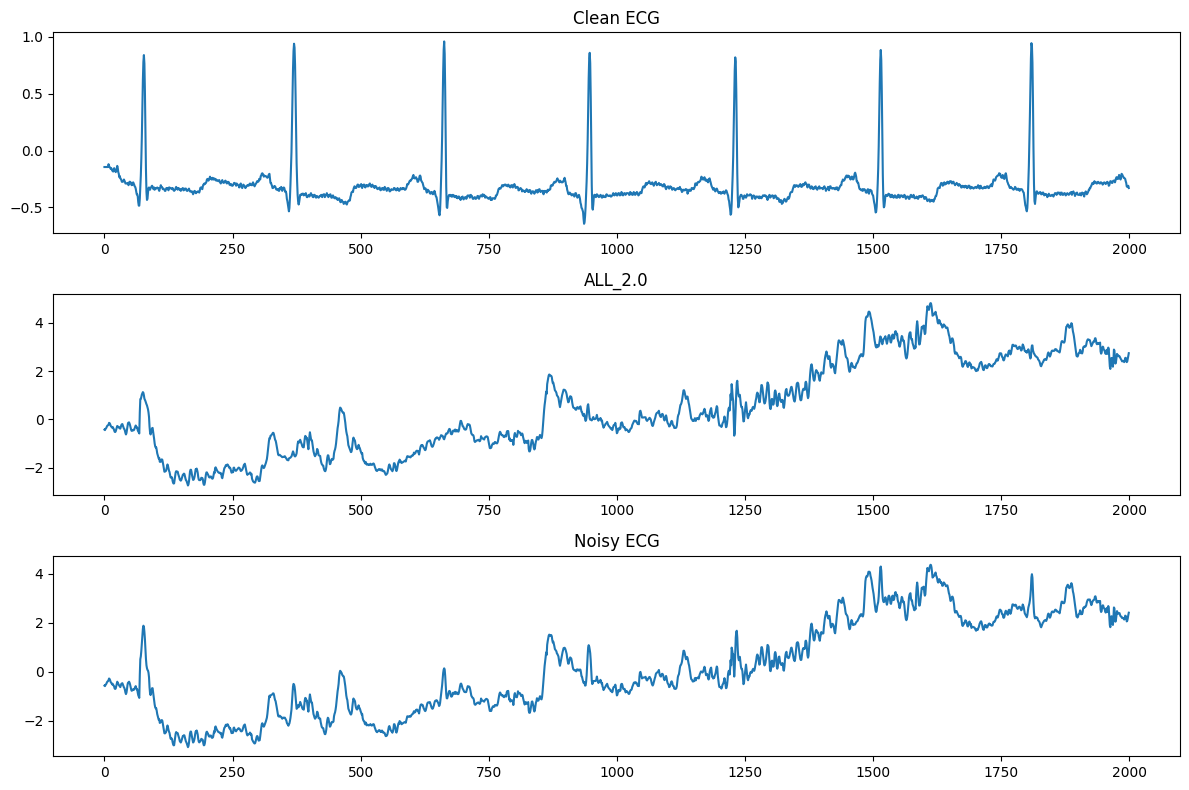

In [ ]:
idx = 15


plt.figure(

    figsize=(12,8)

)


plt.subplot(3,1,1)

plt.plot(

    ecg_signal[:2000]

)

plt.title(

    "Clean ECG"

)


plt.subplot(3,1,2)

plt.plot(

    mixed_artifact_list[idx][:2000]

)

plt.title(

    mixed_artifact_names[idx]

)


plt.subplot(3,1,3)

plt.plot(

    mixed_noisy_ecg_list[idx][:2000]

)

plt.title(

    "Noisy ECG"

)


plt.tight_layout()

plt.show()

In [ ]:
FS = 360


def butter_highpass(

    cutoff,

    fs,

    order=2

):

    nyq = 0.5*fs

    return butter(

        order,

        cutoff/nyq,

        btype='high'

    )


def butter_lowpass(

    cutoff,

    fs,

    order=2

):

    nyq = 0.5*fs

    return butter(

        order,

        cutoff/nyq,

        btype='low'

    )


def bandpass_filter(signal):


    b_hp,a_hp = butter_highpass(

        0.5,

        FS

    )


    b_lp,a_lp = butter_lowpass(

        40,

        FS

    )


    signal = lfilter(

        b_hp,

        a_hp,

        signal

    )


    signal = lfilter(

        b_lp,

        a_lp,

        signal

    )


    return signal

In [ ]:
filtered_ecg_list=[]


for noisy_ecg in noisy_ecg_list:


    filtered_ecg = bandpass_filter(

        noisy_ecg

    )


    filtered_ecg_list.append(

        filtered_ecg

    )


print(

    len(filtered_ecg_list)

)

print(

    filtered_ecg_list[0].shape

)

12
(650000,)


In [ ]:
target_artifact_list=[]


for filtered_ecg in filtered_ecg_list:


    target_artifact=(

        filtered_ecg

        -

        ecg_signal

    )


    target_artifact_list.append(

        target_artifact

    )


print(

    len(target_artifact_list)

)

print(

    target_artifact_list[0].shape

)

12
(650000,)


In [ ]:
mixed_filtered_ecg_list=[]


for noisy_ecg in mixed_noisy_ecg_list:


    filtered_ecg=bandpass_filter(

        noisy_ecg

    )


    mixed_filtered_ecg_list.append(

        filtered_ecg

    )


print(

    len(

        mixed_filtered_ecg_list

    )

)

print(

    mixed_filtered_ecg_list[0].shape

)

16
(650000,)


In [ ]:
mixed_target_artifact_list=[]


for filtered_ecg in mixed_filtered_ecg_list:


    target_artifact=(

        filtered_ecg

        -

        ecg_signal

    )


    mixed_target_artifact_list.append(

        target_artifact

    )


print(

    len(

        mixed_target_artifact_list

    )

)

print(

    mixed_target_artifact_list[0].shape

)

16
(650000,)


In [ ]:
mixed_target_artifact_list=[]


for filtered_ecg in mixed_filtered_ecg_list:


    target_artifact=(

        filtered_ecg

        -

        ecg_signal

    )


    mixed_target_artifact_list.append(

        target_artifact

    )


print(

    len(

        mixed_target_artifact_list

    )

)

print(

    mixed_target_artifact_list[0].shape

)

16
(650000,)


In [ ]:
def create_windows(

    signal,

    window_size=512,

    step=256

):

    windows=[]

    for i in range(

        0,

        len(signal)-window_size,

        step

    ):

        windows.append(

            signal[i:i+window_size]

        )

    return np.array(

        windows

    )

In [ ]:
X_single=[]

Y_single=[]

single_label_list=[]

In [ ]:
for idx,(

    filtered_ecg,

    target_artifact

) in enumerate(

    zip(

        filtered_ecg_list,

        target_artifact_list

    )

):


    X_windows=create_windows(

        filtered_ecg

    )


    Y_windows=create_windows(

        target_artifact

    )


    X_single.append(

        X_windows

    )


    Y_single.append(

        Y_windows

    )


    current_labels=np.full(

        len(X_windows),

        idx

    )


    single_label_list.append(

        current_labels

    )

In [ ]:
X_single=np.concatenate(

    X_single,

    axis=0

)


Y_single=np.concatenate(

    Y_single,

    axis=0

)


single_labels=np.concatenate(

    single_label_list,

    axis=0

)


print(X_single.shape)

print(Y_single.shape)

print(single_labels.shape)

(30456, 512)
(30456, 512)
(30456,)


In [ ]:
X_mix=[]

Y_mix=[]

mixed_label_list=[]

In [ ]:
for idx,(

    filtered_ecg,

    target_artifact

) in enumerate(

    zip(

        mixed_filtered_ecg_list,

        mixed_target_artifact_list

    )

):


    X_windows=create_windows(

        filtered_ecg

    )


    Y_windows=create_windows(

        target_artifact

    )


    X_mix.append(

        X_windows

    )


    Y_mix.append(

        Y_windows

    )


    current_labels=np.full(

        len(X_windows),

        idx

    )


    mixed_label_list.append(

        current_labels

    )

In [ ]:
X_mix=np.concatenate(

    X_mix,

    axis=0

)


Y_mix=np.concatenate(

    Y_mix,

    axis=0

)


mixed_labels=np.concatenate(

    mixed_label_list,

    axis=0

)


print(X_mix.shape)

print(Y_mix.shape)

print(mixed_labels.shape)

(40608, 512)
(40608, 512)
(40608,)


In [ ]:
mixed_labels_shifted = (

    mixed_labels

    +

    12

)

print(

    np.unique(

        mixed_labels_shifted

    )

)

[12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27]


In [ ]:
X_total=np.concatenate(

    [

        X_single,

        X_mix

    ],

    axis=0

)


Y_total=np.concatenate(

    [

        Y_single,

        Y_mix

    ],

    axis=0

)


labels_total=np.concatenate(

    [

        single_labels,

        mixed_labels_shifted

    ],

    axis=0

)


print(X_total.shape)

print(Y_total.shape)

print(labels_total.shape)

(71064, 512)
(71064, 512)
(71064,)


In [ ]:
artifact_names_total=[

"MA_0.25",
"MA_0.5",
"MA_1.0",
"MA_2.0",

"BW_0.25",
"BW_0.5",
"BW_1.0",
"BW_2.0",

"EM_0.25",
"EM_0.5",
"EM_1.0",
"EM_2.0",

"MABW_0.25",
"MABW_0.5",
"MABW_1.0",
"MABW_2.0",

"MAEM_0.25",
"MAEM_0.5",
"MAEM_1.0",
"MAEM_2.0",

"BWEM_0.25",
"BWEM_0.5",
"BWEM_1.0",
"BWEM_2.0",

"ALL_0.25",
"ALL_0.5",
"ALL_1.0",
"ALL_2.0"

]

print(len(artifact_names_total))

28


In [ ]:
unique,counts=np.unique(

    labels_total,

    return_counts=True

)


for u,c in zip(

    unique,

    counts

):

    print(

        artifact_names_total[u],

        "->",

        c

    )

MA_0.25 -> 2538
MA_0.5 -> 2538
MA_1.0 -> 2538
MA_2.0 -> 2538
BW_0.25 -> 2538
BW_0.5 -> 2538
BW_1.0 -> 2538
BW_2.0 -> 2538
EM_0.25 -> 2538
EM_0.5 -> 2538
EM_1.0 -> 2538
EM_2.0 -> 2538
MABW_0.25 -> 2538
MABW_0.5 -> 2538
MABW_1.0 -> 2538
MABW_2.0 -> 2538
MAEM_0.25 -> 2538
MAEM_0.5 -> 2538
MAEM_1.0 -> 2538
MAEM_2.0 -> 2538
BWEM_0.25 -> 2538
BWEM_0.5 -> 2538
BWEM_1.0 -> 2538
BWEM_2.0 -> 2538
ALL_0.25 -> 2538
ALL_0.5 -> 2538
ALL_1.0 -> 2538
ALL_2.0 -> 2538


In [ ]:
print(X_single.shape)

print(X_mix.shape)

print(X_total.shape)

print(labels_total.shape)

(30456, 512)
(40608, 512)
(71064, 512)
(71064,)


In [ ]:
X_train, X_val, \
Y_train, Y_val, \
labels_train, labels_val = train_test_split(

    X_total,

    Y_total,

    labels_total,

    test_size=0.2,

    random_state=42

)

print(X_train.shape)

print(X_val.shape)

print(Y_train.shape)

print(Y_val.shape)

print(labels_train.shape)

print(labels_val.shape)

(56851, 512)
(14213, 512)
(56851, 512)
(14213, 512)
(56851,)
(14213,)


In [ ]:
X_train = torch.tensor(

    X_train,

    dtype=torch.float32

).unsqueeze(1)


Y_train = torch.tensor(

    Y_train,

    dtype=torch.float32

).unsqueeze(1)


X_val = torch.tensor(

    X_val,

    dtype=torch.float32

).unsqueeze(1)


Y_val = torch.tensor(

    Y_val,

    dtype=torch.float32

).unsqueeze(1)


print(X_train.shape)

print(Y_train.shape)

print(X_val.shape)

print(Y_val.shape)

torch.Size([56851, 1, 512])
torch.Size([56851, 1, 512])
torch.Size([14213, 1, 512])
torch.Size([14213, 1, 512])


In [ ]:
class ResidualBlock(nn.Module):

    def __init__(self, channels):

        super().__init__()


        self.conv1 = nn.Conv1d(

            channels,

            channels,

            kernel_size=5,

            padding=2

        )


        self.relu = nn.ReLU()


        self.conv2 = nn.Conv1d(

            channels,

            channels,

            kernel_size=5,

            padding=2

        )


    def forward(self,x):

        identity=x


        out=self.conv1(x)

        out=self.relu(out)


        out=self.conv2(out)


        out=out+identity


        out=self.relu(out)


        return out

In [ ]:
class ResidualCNN(nn.Module):

    def __init__(self):

        super().__init__()


        self.input_conv=nn.Conv1d(

            1,

            32,

            kernel_size=5,

            padding=2

        )


        self.relu=nn.ReLU()


        self.res1=ResidualBlock(32)

        self.res2=ResidualBlock(32)

        self.res3=ResidualBlock(32)


        self.output_conv=nn.Conv1d(

            32,

            1,

            kernel_size=5,

            padding=2

        )


    def forward(self,x):


        x=self.input_conv(x)

        x=self.relu(x)


        x=self.res1(x)

        x=self.res2(x)

        x=self.res3(x)


        x=self.output_conv(x)


        return x

In [ ]:
class ECGDataset(Dataset):

    def __init__(self,X,Y):

        self.X=X

        self.Y=Y


    def __len__(self):

        return len(self.X)


    def __getitem__(self,idx):

        return self.X[idx],self.Y[idx]

In [ ]:
train_dataset=ECGDataset(

    X_train,

    Y_train

)


val_dataset=ECGDataset(

    X_val,

    Y_val

)


train_loader=DataLoader(

    train_dataset,

    batch_size=32,

    shuffle=True

)


val_loader=DataLoader(

    val_dataset,

    batch_size=32,

    shuffle=False

)


print(

    "Train batches:",

    len(train_loader)

)


print(

    "Validation batches:",

    len(val_loader)

)

Train batches: 1777
Validation batches: 445


In [ ]:
device=torch.device(

    "cuda"

    if torch.cuda.is_available()

    else

    "cpu"

)


print(device)


model=ResidualCNN().to(

    device

)


criterion=nn.MSELoss()


optimizer=torch.optim.Adam(

    model.parameters(),

    lr=0.001

)


print(model)

cuda
ResidualCNN(
  (input_conv): Conv1d(1, 32, kernel_size=(5,), stride=(1,), padding=(2,))
  (relu): ReLU()
  (res1): ResidualBlock(
    (conv1): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (relu): ReLU()
    (conv2): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(2,))
  )
  (res2): ResidualBlock(
    (conv1): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (relu): ReLU()
    (conv2): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(2,))
  )
  (res3): ResidualBlock(
    (conv1): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (relu): ReLU()
    (conv2): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(2,))
  )
  (output_conv): Conv1d(32, 1, kernel_size=(5,), stride=(1,), padding=(2,))
)


In [ ]:
epochs = 50

for epoch in range(epochs):

    # ------------------
    # Training
    # ------------------

    model.train()

    train_loss = 0

    for batch_X, batch_Y in train_loader:

        batch_X = batch_X.to(device)

        batch_Y = batch_Y.to(device)


        optimizer.zero_grad()


        predicted_artifact = model(

            batch_X

        )


        artifact_loss = criterion(

            predicted_artifact,

            batch_Y

        )


        recovered_ecg = (

            batch_X

            -

            predicted_artifact

        )


        ideal_clean_ecg = (

            batch_X

            -

            batch_Y

        )


        ecg_loss = criterion(

            recovered_ecg,

            ideal_clean_ecg

        )


        loss = (

            artifact_loss

            +

            ecg_loss

        )


        loss.backward()


        optimizer.step()


        train_loss += loss.item()


    train_loss /= len(

        train_loader

    )


    # ------------------
    # Validation
    # ------------------


    model.eval()

    val_loss = 0


    with torch.no_grad():


        for batch_X, batch_Y in val_loader:


            batch_X = batch_X.to(device)

            batch_Y = batch_Y.to(device)


            predicted_artifact = model(

                batch_X

            )


            artifact_loss = criterion(

                predicted_artifact,

                batch_Y

            )


            recovered_ecg = (

                batch_X

                -

                predicted_artifact

            )


            ideal_clean_ecg = (

                batch_X

                -

                batch_Y

            )


            ecg_loss = criterion(

                recovered_ecg,

                ideal_clean_ecg

            )


            loss = (

                artifact_loss

                +

                ecg_loss

            )


            val_loss += loss.item()


    val_loss /= len(

        val_loader

    )


    print(

        f"Epoch {epoch+1:02d} | "

        f"Train Loss: {train_loss:.6f} | "

        f"Val Loss: {val_loss:.6f}"

    )

Epoch 01 | Train Loss: 0.019239 | Val Loss: 0.015700
Epoch 02 | Train Loss: 0.014547 | Val Loss: 0.014209
Epoch 03 | Train Loss: 0.013847 | Val Loss: 0.013386
Epoch 04 | Train Loss: 0.013386 | Val Loss: 0.013321
Epoch 05 | Train Loss: 0.013091 | Val Loss: 0.012932
Epoch 06 | Train Loss: 0.012859 | Val Loss: 0.012824
Epoch 07 | Train Loss: 0.012619 | Val Loss: 0.012452
Epoch 08 | Train Loss: 0.012484 | Val Loss: 0.012362
Epoch 09 | Train Loss: 0.012347 | Val Loss: 0.012605
Epoch 10 | Train Loss: 0.012214 | Val Loss: 0.012384
Epoch 11 | Train Loss: 0.012106 | Val Loss: 0.012237
Epoch 12 | Train Loss: 0.012017 | Val Loss: 0.012270
Epoch 13 | Train Loss: 0.011935 | Val Loss: 0.011935
Epoch 14 | Train Loss: 0.011869 | Val Loss: 0.011766
Epoch 15 | Train Loss: 0.011813 | Val Loss: 0.011973
Epoch 16 | Train Loss: 0.011731 | Val Loss: 0.011747
Epoch 17 | Train Loss: 0.011674 | Val Loss: 0.011936
Epoch 18 | Train Loss: 0.011656 | Val Loss: 0.011447
Epoch 19 | Train Loss: 0.011586 | Val Loss: 0.

In [ ]:
rmse_list=[]

mse_before=[]

mse_after=[]

corr_list=[]

prd_list=[]

snr_improvement_list=[]


model.eval()


with torch.no_grad():

    for i in range(

        len(X_val)

    ):


        sample = X_val[i].unsqueeze(

            0

        ).to(device)


        pred_artifact = model(

            sample

        )


        pred_artifact = (

            pred_artifact

            .cpu()

            .squeeze()

            .numpy()

        )


        input_ecg = (

            X_val[i]

            .squeeze()

            .cpu()

            .numpy()

        )


        true_artifact = (

            Y_val[i]

            .squeeze()

            .cpu()

            .numpy()

        )


        ideal_clean = (

            input_ecg

            -

            true_artifact

        )


        recovered_ecg = (

            input_ecg

            -

            pred_artifact

        )


        mse_before.append(

            np.mean(

                (

                    input_ecg

                    -

                    ideal_clean

                )**2

            )

        )


        mse_after.append(

            np.mean(

                (

                    recovered_ecg

                    -

                    ideal_clean

                )**2

            )

        )


        rmse=np.sqrt(

            np.mean(

                (

                    recovered_ecg

                    -

                    ideal_clean

                )**2

            )

        )

        rmse_list.append(

            rmse

        )


        corr=np.corrcoef(

            recovered_ecg,

            ideal_clean

        )[0,1]

        corr_list.append(

            corr

        )


        prd=(

            np.sqrt(

                np.sum(

                    (

                        recovered_ecg

                        -

                        ideal_clean

                    )**2

                )

            )

            /

            np.sqrt(

                np.sum(

                    ideal_clean**2

                )

            )

        )*100


        prd_list.append(

            prd

        )


        snr_before=10*np.log10(

            np.sum(

                ideal_clean**2

            )

            /

            np.sum(

                (

                    input_ecg

                    -

                    ideal_clean

                )**2

            )

        )


        snr_after=10*np.log10(

            np.sum(

                ideal_clean**2

            )

            /

            np.sum(

                (

                    recovered_ecg

                    -

                    ideal_clean

                )**2

            )

        )


        snr_improvement=(

            snr_after

            -

            snr_before

        )


        snr_improvement_list.append(

            snr_improvement

        )


print(

"===== UNIVERSAL MODEL RESULTS ====="

)

print()

print(

"Average MSE Before:",

np.mean(mse_before)

)

print(

"Average MSE After :",

np.mean(mse_after)

)

print()

print(

"Average RMSE:",

np.mean(rmse_list)

)

print(

"Average Correlation:",

np.mean(corr_list)

)

print(

"Average PRD:",

np.mean(prd_list)

)

print(

"Average SNR Improvement:",

np.mean(

snr_improvement_list

)

)

===== UNIVERSAL MODEL RESULTS =====

Average MSE Before: 0.3488979
Average MSE After : 0.0057318984

Average RMSE: 0.070676506
Average Correlation: 0.9480180888474526
Average PRD: 19.730076
Average SNR Improvement: 16.396555


In [ ]:
results={

"MA":{"rmse":[],"corr":[],"prd":[]},

"BW":{"rmse":[],"corr":[],"prd":[]},

"EM":{"rmse":[],"corr":[],"prd":[]},

"MABW":{"rmse":[],"corr":[],"prd":[]},

"MAEM":{"rmse":[],"corr":[],"prd":[]},

"BWEM":{"rmse":[],"corr":[],"prd":[]},

"ALL":{"rmse":[],"corr":[],"prd":[]}

}

In [ ]:
model.eval()

with torch.no_grad():

    for i in range(

        len(X_val)

    ):


        sample=X_val[i].unsqueeze(

            0

        ).to(device)


        pred_artifact=model(

            sample

        )


        pred_artifact=(

            pred_artifact

            .cpu()

            .squeeze()

            .numpy()

        )


        input_ecg=(

            X_val[i]

            .squeeze()

            .cpu()

            .numpy()

        )


        true_artifact=(

            Y_val[i]

            .squeeze()

            .cpu()

            .numpy()

        )


        ideal_clean=(

            input_ecg

            -

            true_artifact

        )


        recovered_ecg=(

            input_ecg

            -

            pred_artifact

        )


        rmse=np.sqrt(

            np.mean(

                (

                    recovered_ecg

                    -

                    ideal_clean

                )**2

            )

        )


        corr=np.corrcoef(

            recovered_ecg,

            ideal_clean

        )[0,1]


        prd=(

            np.sqrt(

                np.sum(

                    (

                        recovered_ecg

                        -

                        ideal_clean

                    )**2

                )

            )

            /

            np.sqrt(

                np.sum(

                    ideal_clean**2

                )

            )

        )*100


        label=labels_val[i]


        artifact_type=(

            artifact_names_total[label]

            .split("_")[0]

        )


        results[artifact_type]["rmse"].append(

            rmse

        )

        results[artifact_type]["corr"].append(

            corr

        )

        results[artifact_type]["prd"].append(

            prd

        )


for artifact_type in [

"MA",

"BW",

"EM",

"MABW",

"MAEM",

"BWEM",

"ALL"

]:


    print(

        "\n====",

        artifact_type,

        "===="

    )


    print(

        "RMSE:",

        np.mean(

            results[artifact_type]["rmse"]

        )

    )


    print(

        "Correlation:",

        np.mean(

            results[artifact_type]["corr"]

        )

    )


    print(

        "PRD:",

        np.mean(

            results[artifact_type]["prd"]

        )

    )


==== MA ====
RMSE: 0.062223416
Correlation: 0.9656565824699183
PRD: 17.319466

==== BW ====
RMSE: 0.057960328
Correlation: 0.9732706071295457
PRD: 16.153334

==== EM ====
RMSE: 0.07477332
Correlation: 0.9389706102546415
PRD: 20.875402

==== MABW ====
RMSE: 0.06421084
Correlation: 0.960974215571073
PRD: 17.905443

==== MAEM ====
RMSE: 0.079039946
Correlation: 0.9307842891419887
PRD: 22.064575

==== BWEM ====
RMSE: 0.07643213
Correlation: 0.9371638924904766
PRD: 21.341116

==== ALL ====
RMSE: 0.07983887
Correlation: 0.9298005035960847
PRD: 22.377836


In [ ]:
sample_idx=100

sample=X_val[sample_idx].unsqueeze(

    0

).to(device)


model.eval()

with torch.no_grad():

    pred_artifact=model(

        sample

    )


pred_artifact=(

    pred_artifact

    .cpu()

    .squeeze()

    .numpy()

)


input_ecg=(

    X_val[sample_idx]

    .squeeze()

    .cpu()

    .numpy()

)


true_artifact=(

    Y_val[sample_idx]

    .squeeze()

    .cpu()

    .numpy()

)


ideal_clean=(

    input_ecg

    -

    true_artifact

)


recovered_ecg=(

    input_ecg

    -

    pred_artifact

)

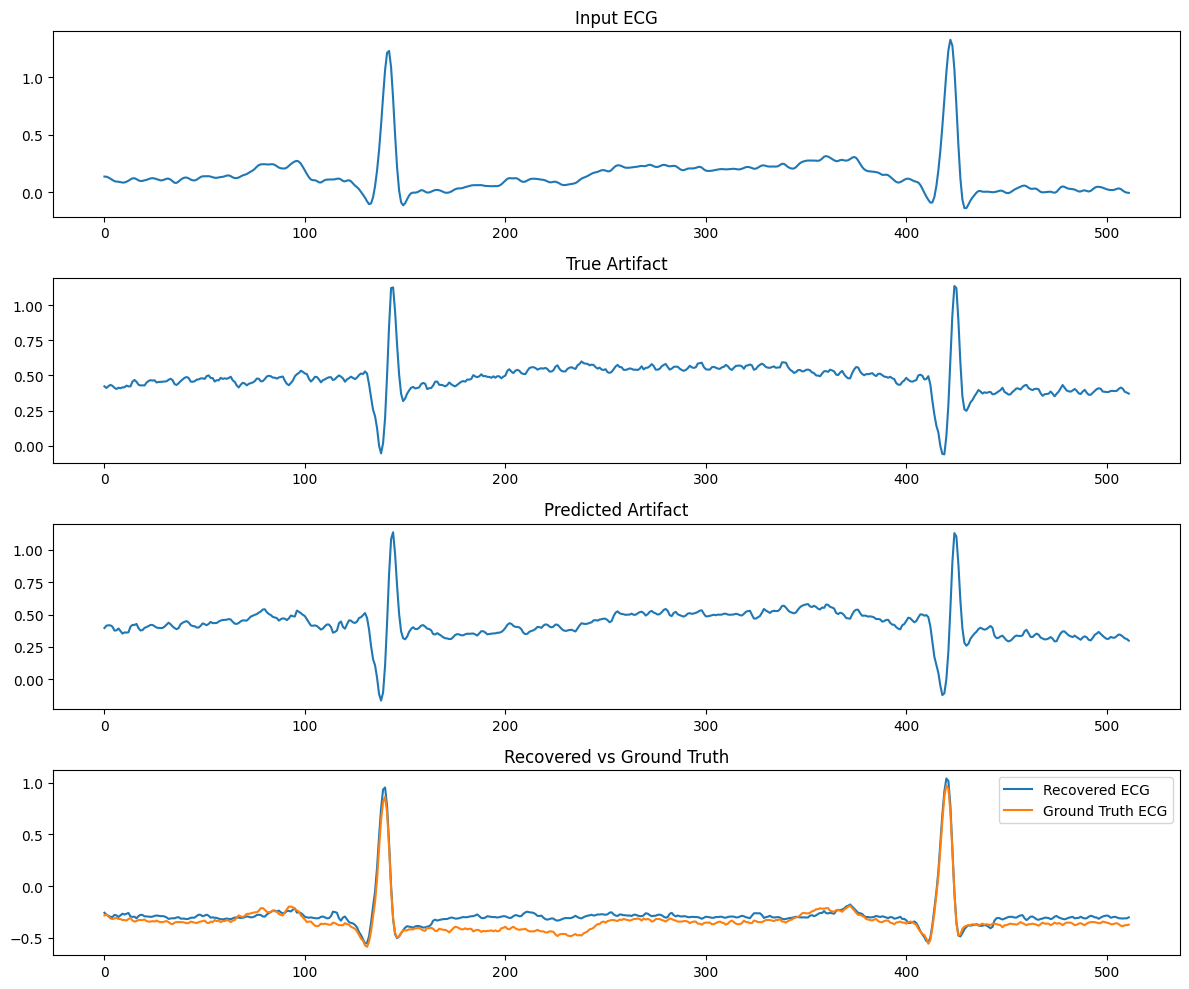

In [ ]:
plt.figure(

    figsize=(12,10)

)


plt.subplot(4,1,1)

plt.plot(

    input_ecg

)

plt.title(

    "Input ECG"

)


plt.subplot(4,1,2)

plt.plot(

    true_artifact

)

plt.title(

    "True Artifact"

)


plt.subplot(4,1,3)

plt.plot(

    pred_artifact

)

plt.title(

    "Predicted Artifact"

)


plt.subplot(4,1,4)

plt.plot(

    recovered_ecg,

    label="Recovered ECG"

)

plt.plot(

    ideal_clean,

    label="Ground Truth ECG"

)

plt.legend()

plt.title(

    "Recovered vs Ground Truth"

)


plt.tight_layout()

plt.show()